Mini-project: simple neural network on MNIST dataset

Understand MNIST dataset + prepare inputs for a neural network

In [24]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [25]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


Load MNIST and convert images to tensors:

In [26]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

Inspect the dataset:

In [27]:
print(len(train_dataset))  # should be 60000

image, label = train_dataset[0]

print(image.shape)  # (1, 28, 28)
print(label)        # 0–9

60000
torch.Size([1, 28, 28])
5


What that means:
- 60000 is the number of training samples (images)
- 1 is the number of channels (greyscale)
- 28 x 28 is the image size

This is our input X.

Visualize samples:

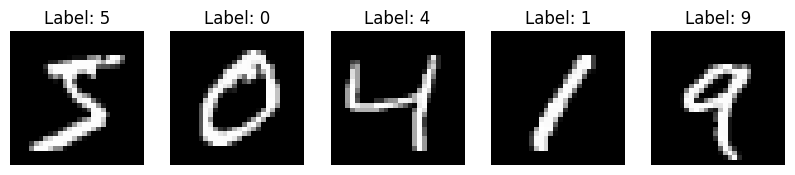

In [28]:
fig, ax = plt.subplots(1, 5, figsize=(10, 2))

for i in range(5):
    img, lbl = train_dataset[i]
    ax[i].imshow(img.squeeze(), cmap="gray")
    ax[i].set_title(f"Label: {lbl}")
    ax[i].axis("off")

plt.show()

Create DataLoader: this is how we feed batches to the model.

In [29]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

Inspect one batch:

In [30]:
images, labels = next(iter(train_loader))

print(images.shape)  # (32, 1, 28, 28)
print(labels.shape)  # (32,)

torch.Size([32, 1, 28, 28])
torch.Size([32])


How to interpret this:
- 32: batch size
- 1: number of channels
- 28 x 28: image size

So shape for a single batch is: (batch_size, channels, height, width) = (32, 1, 28, 28)

60000 / 32 means there are 1875 batches per epoch (1 epoch = one full pass over dataset = seeing all 60,000 images once)

Flatten images: neural networks expect vectors, not images

In [31]:
# images_flat = images.view(32, -1)
images_flat = images.view(images.size(0), -1) # more robust version (works for any batch size, not just 32)

print(images_flat.shape)  # (32, 784)

# manual flatten just for understanding — model already handles it

torch.Size([32, 784])


28 × 28 = 784 features so flatten shape is (batch_size, height x width) = (32, 28 x 28 = 784) 

-> This is our input vector X.

Summary:
- Dataset: 60,000 training images
- Input shape: (1, 28, 28)
- Batch shape: (32, 1, 28, 28)
- Flattened input: (32, 784)
- Each image = 784 features

Next: seeing images -> model -> logits -> loss

Build simple MLP model:

In [32]:
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Flatten(),               # no need to flatten manually
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)           # final output size is 10 because digits are 0-9
).to(device)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


What this does:
- nn.Flatten() turns each 28 x 28 image into a vector of size 784 (the step we did earlier is done in the model so we don't have to do it manually)
- nn.Linear(28 * 28, 128) maps input to 128 hidden units
- nn.ReLU() adds nonlinearity (remember: without activation functions, the entire network would be equivalent to a single linear function, no matter how many layers → cannot learn complex patterns!)
- nn.Linear(128, 10) outputs 10 scores, one per digit class -> important: the final output is 10 logits, not probabilities.

Take one batch from the dataloader:

In [33]:
images, labels = next(iter(train_loader))

print("images shape before sending to device:", images.shape)
print("labels shape before sending to device:", labels.shape)

images = images.to(device)
labels = labels.to(device)

print("images shape:", images.shape)
print("labels shape:", labels.shape)
print("first 10 labels:", labels[:10])

images shape before sending to device: torch.Size([32, 1, 28, 28])
labels shape before sending to device: torch.Size([32])
images shape: torch.Size([32, 1, 28, 28])
labels shape: torch.Size([32])
first 10 labels: tensor([8, 3, 2, 9, 1, 0, 2, 6, 0, 7], device='mps:0')


What we see here:
- For MNIST, images.shape is usually: [batch_size, 1, 28, 28] = torch.Size([32, 1, 28, 28])
- and labels: [batch_size] = torch.Size([32])

We move tensors to a device (CPU/GPU) so that computations happen on that device. 

All tensors and the model must be on the same device; otherwise, PyTorch will raise an error.

Run a forward pass = compute predictions:

In [34]:
outputs = model(images)

print("output shape:", outputs.shape)
print(outputs[:2])

output shape: torch.Size([32, 10])
tensor([[-0.1334,  0.0353,  0.1495,  0.0147,  0.0325,  0.2497,  0.0350,  0.0671,
         -0.1370, -0.1621],
        [-0.0058, -0.0106, -0.0049, -0.0164,  0.0725,  0.1930, -0.0754, -0.0534,
         -0.0938, -0.0834]], device='mps:0', grad_fn=<SliceBackward0>)


The output shape is [batch_size, 10]: each row contains 10 raw scores for one image.

Get predicted classes: even before training we can check what class the model picks

In [35]:
preds = torch.argmax(outputs, dim=1)

print("predicted classes:", preds[:10])
print("true labels:      ", labels[:10])

predicted classes: tensor([5, 5, 5, 5, 5, 5, 0, 5, 5, 0], device='mps:0')
true labels:       tensor([8, 3, 2, 9, 1, 0, 2, 6, 0, 7], device='mps:0')


Very random for now, which is normal.

Compute the loss:

For multiclass classification like MNIST, use CrossEntropyLoss.

In [36]:
criterion = nn.CrossEntropyLoss()
loss = criterion(outputs, labels)

print("loss:", loss.item())

loss: 2.324212074279785


Important: nn.CrossEntropyLoss() expects:
- raw logits of shape [batch_size, num_classes]
- integer labels of shape [batch_size]

So do not apply softmax before the loss.

Inspect probabilities for one image:

In [37]:
probs = torch.softmax(outputs, dim=1)

print("probabilities for first image:")
print(probs[0])
print("sum:", probs[0].sum().item())
print("predicted class:", torch.argmax(probs[0]).item())
print("true label:", labels[0].item())

probabilities for first image:
tensor([0.0855, 0.1012, 0.1135, 0.0992, 0.1010, 0.1255, 0.1012, 0.1045, 0.0852,
        0.0831], device='mps:0', grad_fn=<SelectBackward0>)
sum: 1.0
predicted class: 5
true label: 8


tensor([0.1055, 0.1124, 0.0995, ..., 0.1103]) is a probability distribution over the 10 digits (0 to 9):

| index | meaning | probability |
|-------|---------|-------------|
| 0     | digit 0 | 0.1055      |
| 1     | digit 1 | 0.1124      |
| 2     | digit 2 | 0.1068      |
| ...   | ...     | ...         |
| 9     | digit 9 | 0.1103      |

How to read it: the model is saying "I think this image is..." 
- 11.2% for digit 1 (highest)
- 11.0% for digit 9
- ~10% for everything else

Why prediction = 1: torch.argmax(probs[0]) picks the highest probability and here 0.1124 (index 1) = highest

Plotting a few images with true and predicted labels:

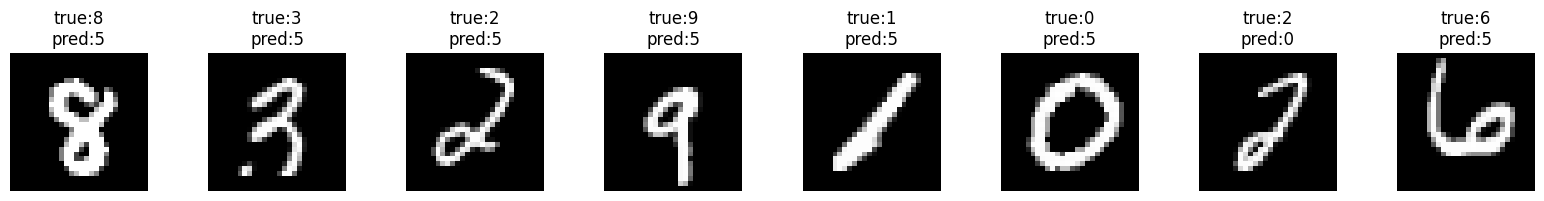

In [38]:
import matplotlib.pyplot as plt

images_cpu = images[:8].cpu()
labels_cpu = labels[:8].cpu()
preds_cpu = preds[:8].cpu()

fig, axes = plt.subplots(1, 8, figsize=(16, 2))

for i, ax in enumerate(axes):
    ax.imshow(images_cpu[i].squeeze(), cmap="gray")
    ax.set_title(f"true:{labels_cpu[i].item()}\npred:{preds_cpu[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Next: add optimizer

In [39]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

1 epoch training loop:

In [41]:
# Move model to GPU (or CPU if no GPU available)
model.to(device)

# Set model to training mode (important for layers like dropout or batchnorm later)
model.train()

# Initialize tracking variables
running_loss = 0.0   # accumulate loss over all batches
correct = 0          # count correct predictions
total = 0            # count total samples

printed_grads = False # set to True to print gradients

# Loop over batches of data
for images, labels in train_loader:

    # Move data to same device as model
    images = images.to(device)
    labels = labels.to(device)

    # Reset gradients from previous step (PyTorch accumulates gradients by default)
    optimizer.zero_grad()

    # FORWARD PASS: input -> model -> predictions (logits)
    logits = model(images)

    # Compute loss between predictions and true labels
    loss = criterion(logits, labels)

    # BACKWARD PASS: compute gradients of loss w.r.t ALL model parameters
    loss.backward()

    # print gradients
    if not printed_grads:
        print("Gradients after loss.backward():")
        for name, param in model.named_parameters():
            if param.grad is not None:
                print(name, param.grad.shape, param.grad.norm().item())
        printed_grads = True

    # UPDATE STEP: use gradients to update weights (gradient descent step)
    optimizer.step()

    # Accumulate loss (convert tensor to Python float)
    running_loss += loss.item()

    # Get predicted class (highest logit)
    preds = logits.argmax(dim=1)

    # Count how many predictions are correct
    correct += (preds == labels).sum().item()

    # Count total number of samples processed
    total += labels.size(0)


# Average loss over all batches
epoch_loss = running_loss / len(train_loader)

# Compute accuracy over all samples
epoch_acc = correct / total

# Print results
print(f"Epoch loss: {epoch_loss:.4f}")
print(f"Epoch accuracy: {epoch_acc:.4f}")

Gradients after loss.backward():
1.weight torch.Size([128, 784]) 0.03883497789502144
1.bias torch.Size([128]) 0.0046375771053135395
3.weight torch.Size([10, 128]) 0.07353087514638901
3.bias torch.Size([10]) 0.005227814894169569
Epoch loss: 0.1295
Epoch accuracy: 0.9623


What we see:
- all trainable parameters have gradients
- gradient shapes match parameter shapes
- loss.backward() is computing them for the whole model and fills param.grad

Our 1 epoch training training also worked well: loss = 0.1295 and accuracy = 0.9623 

That means the training loop is functioning and learning fast.

Check activation:

Reminder: our model is

(0): Flatten(start_dim=1, end_dim=-1)

(1): Linear(in_features=784, out_features=128, bias=True)

(2): ReLU()

(3): Linear(in_features=128, out_features=10, bias=True)

In [56]:
images, labels = next(iter(train_loader))
images = images.to(device)

z1 = model[1](model[0](images)) # linear output
a1 = model[2](z1)               # after ReLU

print("z1 min/max:", z1.min().item(), z1.max().item())
print("a1 min/max:", a1.min().item(), a1.max().item())

z1 min/max: -16.15043067932129 7.470529556274414
a1 min/max: 0.0 7.470529556274414


Before ReLU: z1 contains both negative and positive values => That’s what a linear layer should produce.

After ReLU: a1 contains zero for everything that was negative and unchanged positive values

That’s exactly what ReLU does: $\mathrm{ReLU}(z) = \max(0, z)$

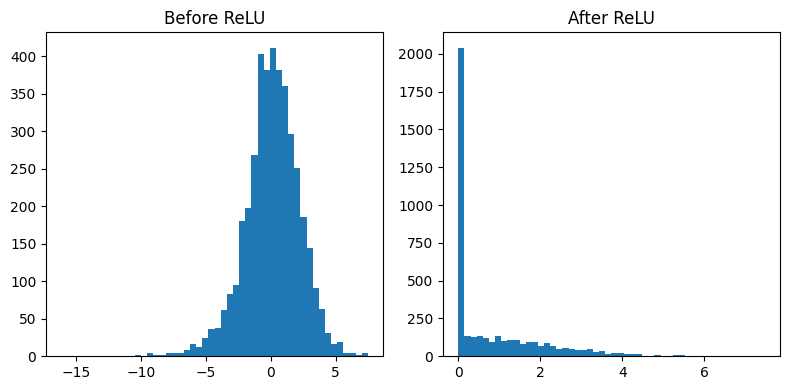

In [57]:
f, ax = plt.subplots(1, 2, figsize=(8,4))

ax[0].hist(z1.detach().cpu().numpy().ravel(), bins=50)
ax[0].set_title("Before ReLU")

ax[1].hist(a1.detach().cpu().numpy().ravel(), bins=50)
ax[1].set_title("After ReLU")

plt.tight_layout()
plt.show()

Left: Before ReLU

The distribution spreads across negative and positive values. That shows the linear layer is producing a full range of pre-activations.

Right: After ReLU

There is a big spike at 0. That means many neurons had negative pre-activation: ReLU set them to zero. The rest of the distribution is only positive


Make a second model with no ReLU activation:

In [50]:
model_no_relu = nn.Sequential(
    nn.Flatten(),               # no need to flatten manually
    nn.Linear(28 * 28, 128),
    # nn.ReLU(), # REMOVED
    nn.Linear(128, 10)           # final output size is 10 because digits are 0-9
).to(device)

print(model_no_relu)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): Linear(in_features=128, out_features=10, bias=True)
)


Then take a fresh optimizer and train for 1 epoch like before:

In [51]:
optimizer_no_relu = torch.optim.Adam(model_no_relu.parameters(), lr=1e-3)

In [52]:
model_no_relu.train()

running_loss_no_relu = 0.0
correct_no_relu = 0
total_no_relu = 0

for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    images = images.view(images.size(0), -1)

    optimizer_no_relu.zero_grad()
    logits = model_no_relu(images)
    loss = criterion(logits, labels)
    loss.backward()
    optimizer_no_relu.step()

    running_loss_no_relu += loss.item()
    preds = logits.argmax(dim=1)
    correct_no_relu += (preds == labels).sum().item()
    total_no_relu += labels.size(0)

epoch_loss_no_relu = running_loss_no_relu / len(train_loader)
epoch_acc_no_relu = correct_no_relu / total_no_relu

print(f"No ReLU - loss: {epoch_loss_no_relu:.4f}")
print(f"No ReLU - accuracy: {epoch_acc_no_relu:.4f}")

No ReLU - loss: 0.3643
No ReLU - accuracy: 0.8979


Compare performance with and without ReLU:

In [53]:
print(f"With ReLU    - loss: {epoch_loss:.4f}, acc: {epoch_acc:.4f}")
print(f"Without ReLU - loss: {epoch_loss_no_relu:.4f}, acc: {epoch_acc_no_relu:.4f}")

With ReLU    - loss: 0.1295, acc: 0.9623
Without ReLU - loss: 0.3643, acc: 0.8979


After 1 epoch of training:

- With ReLU:
  - loss = 0.1295
  - accuracy = 0.9623

- Without ReLU:
  - loss = 0.3643
  - accuracy = 0.8979

The model with ReLU learns faster and achieves better performance.

Without ReLU, the model becomes a composition of linear layers, which is equivalent to a single linear transformation.  
It cannot capture complex patterns in the data, leading to worse performance.

Even after only one epoch, the difference is already significant, highlighting the importance of non-linearity in neural networks.